### Weekly Natural Gas Monitor — Next-Quarter Monte Carlo

> **Are U.S. natural gas conditions tightening or loosening over the next quarter, and is the move expected, elevated, or extreme?**

Core outputs:
- Historical storage and price-pressure monitor
- Supply vs demand diagnostics
- Balance chart
- Next-quarter Monte Carlo forecast with expected, min, max, and percentile bands
- Energy Atlas-style signal table for weekly reporting

Modeling note: this version treats price as a **storage-driven pressure index / price proxy**, not a precise Henry Hub point forecast. The goal is direction and extremeness, not exact price prediction.


In [57]:
# Imports

import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import calibrate_reference_scenario

from weather_data import (
    build_region_weather_monthly,
    merge_weather_into_monthly_panel,
    estimate_weather_demand_sensitivity,
)

## 1. Report configuration

In [58]:
# -----------------------------
# Weekly report settings
# -----------------------------

CALIBRATION_START = "2018-01"
CALIBRATION_END = None

REPORT_LOOKBACK_MONTHS = 36
FORECAST_MONTHS = 3
N_MONTE_CARLO = 500
MC_SEED = 42

REPORT_TITLE = "Natural Gas Weekly Monitor"
REPORT_DATE = pd.Timestamp.today().normalize()

# Forward Monte Carlo scenario assumptions
# These are broad scenario assumptions, not one-month hand tuning.
BASE_FORWARD = {
    "lng_export_pct": 0.00,
    "demand_sigma": 0.00,
    "supply_pct": 0.00,
    "pipeline_capacity_pct": 0.00,
}

COLD_LNG_FORWARD = {
    "lng_export_pct": 0.15,
    "demand_sigma": 1.00,
    "supply_pct": 0.00,
    "pipeline_capacity_pct": 0.00,
}

LOOSE_SUPPLY_FORWARD = {
    "lng_export_pct": 0.00,
    "demand_sigma": -0.50,
    "supply_pct": 0.03,
    "pipeline_capacity_pct": 0.00,
}

plt.rcParams["figure.figsize"] = (12, 5)


### Retrieve Region Weather Monthly data

In [59]:
weather_monthly = build_region_weather_monthly(
    stations_csv="major_airports_by_state_ghcnd.csv",
    region="all",
    start="2018-01-01",
    cache_dir="data/raw/noaa/stations",
)


## 2. Simulator core

The simulator has two modes:

### Historical backtest mode
Uses actual EIA monthly production, demand, LNG exports, and storage history to test whether the model captures broad physical dynamics.

### Forward simulation mode
Uses calibrated baseline parameters and random demand/weather variation to simulate next-quarter paths.

Price is represented as a **pressure proxy** derived from storage tightness and storage change.


In [60]:
DAYS_PER_MONTH = 30


class GasMarket:
    """
    Monthly natural gas balance simulator.

    Core chain:
        supply -> delivered supply -> demand -> storage change -> price pressure

    This model estimates directional market pressure, not exact Henry Hub prices.
    """

    def __init__(self, scenario):
        self.scenario = scenario

        self.storage = float(scenario.get("initial_storage", 3000.0))
        self.storage_capacity = float(scenario.get("storage_capacity", 4200.0))
        self.max_injection = float(scenario.get("max_injection", 300.0))
        self.max_withdrawal = float(scenario.get("max_withdrawal", 500.0))

        self.base_price = float(scenario.get("base_price", 3.00))
        self.price = self.base_price

        self.history = []

    def _historical_row(self, month):
        if not self.scenario.get("use_historical_drivers", False):
            return None
        panel = self.scenario.get("historical_panel")
        if panel is None or month >= len(panel):
            return None
        return panel.iloc[month]


    def supply(self, month):
        """
        Production / supply side.
    
        Historical mode: uses observed production (no noise unless explicitly enabled).
        Forward mode: uses base supply + structural shift + persistent noise.
        """
        row = self._historical_row(month)
    
        # --- 1. Base supply ---
        if row is not None and "production_bcf" in row:
            base_supply = float(row["production_bcf"])
            use_noise = bool(self.scenario.get("historical_supply_noise", False))
        else:
            base_supply = float(self.scenario.get("base_supply", 3100.0))
            use_noise = True
    
        # --- 2. Structural shift (slow-moving) ---
        supply_shift_pct = float(self.scenario.get("supply_shift_pct", 0.0))
        base_supply *= (1.0 + supply_shift_pct)
    
        # --- 3. Deterministic shock (e.g., freeze-off, outage) ---
        shock = float(self.scenario.get("supply_shock", 0.0))
    
        # --- 4. Stochastic noise (persistent, not white noise) ---
        supply_noise = 0.0
    
        if use_noise:
            noise_std_bcf = float(self.scenario.get("supply_noise_bcf", 0.0))
            noise_std_pct = float(self.scenario.get("supply_noise_pct", 0.0))
    
            # Persistent noise (AR(1)-like)
            prev_noise = getattr(self, "_supply_noise_state", 0.0)
            persistence = float(self.scenario.get("supply_noise_persistence", 0.6))
    
            new_noise = 0.0
            if noise_std_bcf > 0:
                new_noise += np.random.normal(0.0, noise_std_bcf)
            if noise_std_pct > 0:
                new_noise += np.random.normal(0.0, abs(base_supply) * noise_std_pct)
    
            supply_noise = persistence * prev_noise + (1 - persistence) * new_noise
            self._supply_noise_state = supply_noise
    
        # --- 5. Final supply ---
        return max(0.0, base_supply + shock + supply_noise)

    def demand(self, month):
        """
        Demand side.

        Priority order:
        1. Weather-driven demand when use_weather_demand=True and HDD/CDD are present.
        2. Historical EIA demand replay.
        3. Seasonal fallback with stochastic residual.

        The returned value is total call on supply:
            domestic demand + LNG exports
        """
        row = self._historical_row(month)
        use_weather = bool(self.scenario.get("use_weather_demand", False))

        if row is not None and use_weather and "hdd" in row and "cdd" in row:

            hdd_sens = float(self.scenario.get("hdd_sensitivity", 0.0)) * float(self.scenario.get("hdd_sensitivity_scale", 1.0))
            cdd_sens = float(self.scenario.get("cdd_sensitivity", 0.0)) * float(self.scenario.get("cdd_sensitivity_scale", 1.0))
            
            cdd_multiplier = float(self.scenario.get("cdd_power_multiplier", 1.2))
            
            hdd = float(row["hdd"])
            cdd = float(row["cdd"])
            
            domestic_demand = (
                float(self.scenario.get("weather_base_demand", self.scenario.get("base_demand", 2900.0)))
                + hdd_sens * hdd
                + cdd_sens * cdd_multiplier * cdd
            )

            
            # Minor realism update: residual demand uncertainty not explained by HDD/CDD.
            demand_noise_bcf = float(self.scenario.get("demand_noise_bcf", 0.0))
            if demand_noise_bcf > 0:
                domestic_demand += np.random.normal(0.0, demand_noise_bcf)

        elif row is not None and "demand_bcf" in row:
            # Historical replay uses actual EIA domestic demand.
            domestic_demand = float(row["demand_bcf"])

        else:
            base_demand = float(self.scenario.get("base_demand", 2900.0))
            seasonal_factors = self.scenario.get(
                "seasonal_factors",
                [1.35, 1.25, 1.05, 0.85, 0.75, 0.80, 0.95, 1.00, 0.85, 0.90, 1.05, 1.30],
            )
            raw_factor = float(seasonal_factors[month % 12])
            seasonal_strength = float(self.scenario.get("seasonal_strength", 1.0))
            seasonal_factor = 1.0 + seasonal_strength * (raw_factor - 1.0)

            weather_shock = random.gauss(
                float(self.scenario.get("weather_mean", 0.0)),
                float(self.scenario.get("weather_volatility", 80.0))
                * float(self.scenario.get("weather_volatility_scale", 1.0)),
            )
            domestic_demand = base_demand * seasonal_factor + weather_shock

        if row is not None and "lng_exports_bcf" in row:
            lng_exports = float(row["lng_exports_bcf"])
        else:
            lng_exports = float(self.scenario.get("lng_exports", 400.0))

        return max(0.0, domestic_demand + lng_exports)

    def pipeline_constraint(self, raw_supply):
        pipeline_capacity = float(self.scenario.get("pipeline_capacity", 3400.0))
        return min(raw_supply, pipeline_capacity)

    def estimate_price_pressure(self, storage_change):
        """
        Price-pressure proxy.

        This is not intended as a precise Henry Hub forecast.
        It measures directional pressure from inventory tightness and storage flows.
        """
        base_price = float(self.scenario.get("base_price", 3.00))
        storage_ratio = self.storage / self.storage_capacity if self.storage_capacity > 0 else 0.5

        target_ratio = float(self.scenario.get("target_storage_ratio", 0.55))
        storage_tightness = target_ratio - storage_ratio

        storage_sensitivity = float(self.scenario.get("storage_price_sensitivity", 2.0))
        flow_sensitivity = float(self.scenario.get("storage_change_price_sensitivity", 0.001))

        tightness = max(0.0, storage_tightness)
        convexity_factor = float(self.scenario.get("price_convexity_factor", 0.0))
        convexity_pressure = convexity_factor * (tightness ** 2)
        
        raw_price = (
            base_price
            + storage_sensitivity * storage_tightness
            - flow_sensitivity * storage_change
            + convexity_pressure
        )

        inertia = float(self.scenario.get("price_inertia", 0.65))
        estimated_price = inertia * self.price + (1.0 - inertia) * raw_price

        price_floor = float(self.scenario.get("price_floor", 0.50))
        price_cap = float(self.scenario.get("price_cap", 12.00))

        return max(price_floor, min(price_cap, estimated_price))

    def monthly_step(self, month):
        storage_start = self.storage

        raw_supply = self.supply(month)
        delivered_supply = self.pipeline_constraint(raw_supply)
        demand = self.demand(month)
        balance = delivered_supply - demand

        tight_threshold = self.scenario.get("tight_balance_threshold", -300)
        loose_threshold = self.scenario.get("loose_balance_threshold", 300)
        
        if balance < tight_threshold:
            regime = "tight"
        elif balance > loose_threshold:
            regime = "loose"
        else:
            regime = "neutral"
        
        if balance > 0:
            storage_change = min(balance, self.storage_capacity - self.storage, self.max_injection)
        else:
            storage_change = -min(-balance, self.storage, self.max_withdrawal)

        # Minor realism update: damp storage response slightly to avoid over-aggressive monthly moves.
        storage_response_factor = float(self.scenario.get("storage_response_factor", 1.0))
        storage_change *= storage_response_factor

        # Keep storage within physical bounds after damping.
        self.storage = min(self.storage_capacity, max(0.0, self.storage + storage_change))
        self.price = self.estimate_price_pressure(storage_change)

        storage_ratio = self.storage / self.storage_capacity if self.storage_capacity > 0 else np.nan

        self.history.append({
            "month": month + 1,
            "regime": regime,
            "price": round(self.price, 3),
            "raw_supply_bcf": round(raw_supply, 1),
            "delivered_supply_bcf": round(delivered_supply, 1),
            "demand_bcf": round(demand, 1),
            "balance_bcf": round(balance, 1),
            "storage_start_bcf": round(storage_start, 1),
            "storage_bcf": round(self.storage, 1),
            "storage_change_bcf": round(storage_change, 1),
            "storage_ratio": round(storage_ratio, 3),
            "pipeline_capacity_bcf": self.scenario.get("pipeline_capacity", 3400.0),
            "lng_exports_bcf": self.scenario.get("lng_exports", 400.0),
        })


def run_scenario(name, scenario, months=24, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    market = GasMarket(scenario)
    for month in range(months):
        market.monthly_step(month)

    df = pd.DataFrame(market.history)
    df["scenario"] = name
    return df

## 3. Load EIA data and calibrate baseline scenario

This uses your `calibration.py` file, which calls your EIA natural gas data retrieval layer and returns:

1. `base_scenario` — simulator-ready parameters
2. `monthly_df` — cleaned monthly EIA history


In [61]:
base_scenario, monthly_df = calibrate_reference_scenario(
    start=CALIBRATION_START,
    end=CALIBRATION_END,
)

monthly_df = monthly_df.copy()
monthly_df.index = pd.to_datetime(monthly_df.index)

print(monthly_df.tail())
print("\nCalibrated baseline scenario keys:")
print(sorted(base_scenario.keys()))


            production_bcf  demand_bcf  industrial_demand_bcf  storage_bcf  \
2025-10-01        3327.295    2443.231              610.80775         3905   
2025-11-01        3308.316    2782.526              695.63150         3913   
2025-12-01        3460.493    3498.325              874.58125         3364   
2026-01-01        3363.241    3785.289              946.32225         2454   
2026-02-01        3080.138    3109.686              777.42150         1876   

            lng_exports_bcf  henry_hub_price  storage_change_bcf  
2025-10-01          503.520         3.199091               354.0  
2025-11-01          525.089         3.794118                 8.0  
2025-12-01          569.267         4.263810              -549.0  
2026-01-01          539.203         7.717895              -910.0  
2026-02-01          493.617         3.621579              -578.0  

Calibrated baseline scenario keys:
['base_demand', 'base_price', 'base_supply', 'calibration_config', 'calibration_end', 'calibr

### Add Monthly Weather to Reference Scenario

In [62]:
monthly_with_weather = merge_weather_into_monthly_panel(
    monthly_df,
    weather_monthly,
    region="lower_48",
)
monthly_with_weather.index = pd.to_datetime(monthly_with_weather.index)

weather_params = estimate_weather_demand_sensitivity(monthly_with_weather)

# Use HDD/CDD in forward mode, but lightly damp the fitted coefficients.
# This keeps weather directionality while avoiding demand overestimation in peaks.
base_scenario.update(weather_params)
base_scenario["hdd_sensitivity_scale"] = 0.80
base_scenario["cdd_sensitivity_scale"] = 0.85

print("Weather demand parameters:")
for k, v in weather_params.items():
    print(f"{k}: {v:,.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Weather demand parameters:
demand_intercept_bcf: 1,973.6705
hdd_sensitivity_bcf_per_hdd: 1.5964
cdd_sensitivity_bcf_per_cdd: 1.3017
weather_model_residual_std_bcf: 152.3032
weather_model_r2: 0.8785


### Weather / demand diagnostic

This chart uses standardized HDD/CDD so the relationship to demand is easier to inspect visually.


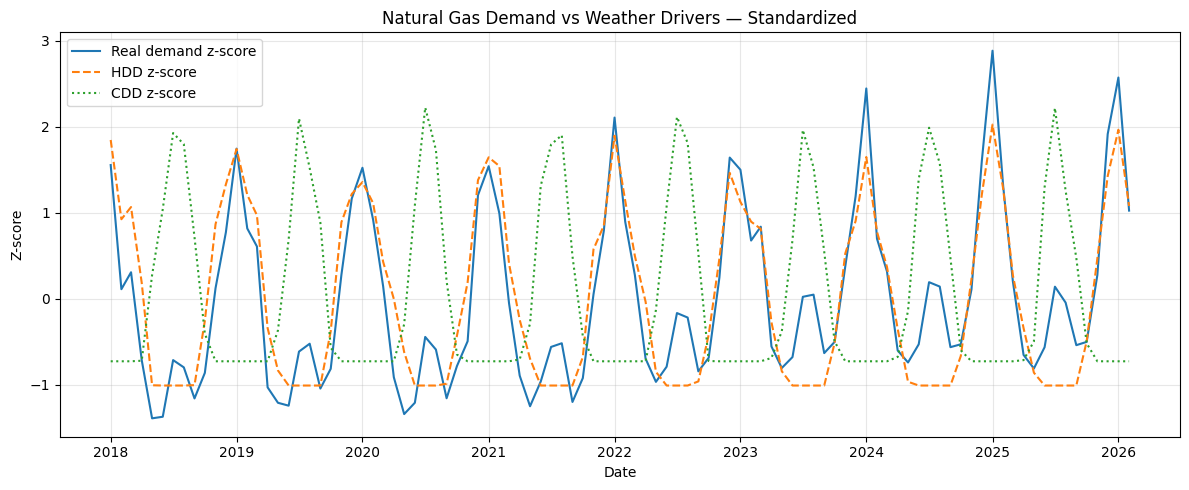

In [63]:
def plot_demand_vs_weather(monthly_with_weather):
    df = monthly_with_weather.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    z_hdd = (df["hdd"] - df["hdd"].mean()) / df["hdd"].std(ddof=1)
    z_cdd = (df["cdd"] - df["cdd"].mean()) / df["cdd"].std(ddof=1)
    z_demand = (df["demand_bcf"] - df["demand_bcf"].mean()) / df["demand_bcf"].std(ddof=1)

    plt.figure(figsize=(12, 5))
    plt.plot(df.index, z_demand, label="Real demand z-score")
    plt.plot(df.index, z_hdd, linestyle="--", label="HDD z-score")
    plt.plot(df.index, z_cdd, linestyle=":", label="CDD z-score")
    plt.title("Natural Gas Demand vs Weather Drivers — Standardized")
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_demand_vs_weather(monthly_with_weather)

## 4. Scenario builders

These helper functions keep historical backtests, reporting charts, and forward Monte Carlo forecasts separate.


In [64]:
def make_backtest_scenario(base_scenario, monthly_df):
    s = base_scenario.copy()

    # Replay actual EIA drivers month-by-month.
    # Historical mode uses actual demand, not the weather-estimated demand.
    s["use_historical_drivers"] = True
    s["use_weather_demand"] = False
    s["historical_panel"] = monthly_df.copy()

    # Start from the first historical storage value for clean backtest comparison.
    s["initial_storage"] = float(monthly_df["storage_bcf"].iloc[0])

    # No random weather/noise during historical replay.
    s["weather_mean"] = 0.0
    s["weather_volatility"] = 0.0
    s["weather_volatility_scale"] = 0.0
    s["demand_noise_bcf"] = 0.0
    s["supply_noise_pct"] = 0.0
    s["supply_noise_bcf"] = 5.0

    # General pressure model defaults.
    s["target_storage_ratio"] = 0.55
    s["storage_price_sensitivity"] = 2.0
    s["storage_change_price_sensitivity"] = 0.001
    s["price_inertia"] = 0.65
    s["seasonal_strength"] = 0.90
    s["price_convexity_factor"] = 3.0

    # Mild storage damping to avoid over-aggressive monthly injections/draws.
    s["storage_response_factor"] = 0.95

    return s


def make_forward_scenario(
    base_scenario,
    *,
    initial_storage,
    lng_export_pct=0.0,
    demand_sigma=0.0,
    supply_pct=0.0,
    pipeline_capacity_pct=0.0,
    weather_volatility_scale=1.0,
):
    s = base_scenario.copy()

    # Forward mode will receive a generated weather panel inside Monte Carlo.
    s["use_historical_drivers"] = False
    s["use_weather_demand"] = True
    s.pop("historical_panel", None)

    s["initial_storage"] = float(initial_storage)
    s["lng_exports"] = float(s["lng_exports"] * (1.0 + lng_export_pct))
    s["base_demand"] = float(s["base_demand"] + demand_sigma * s.get("weather_volatility", 0.0))
    s["base_supply"] = float(s["base_supply"] * (1.0 + supply_pct))
    s["pipeline_capacity"] = float(s["pipeline_capacity"] * (1.0 + pipeline_capacity_pct))

    # General pressure model defaults. These may be overwritten by grid search later.
    s["target_storage_ratio"] = 0.55
    s["storage_price_sensitivity"] = 2.0
    s["storage_change_price_sensitivity"] = 0.001
    s["price_inertia"] = 0.65
    s["seasonal_strength"] = 0.90
    s["weather_volatility_scale"] = weather_volatility_scale

    # Minor realism updates for forward uncertainty.
    s["storage_response_factor"] = 0.95
    s["demand_noise_bcf"] = 75.0
    s["supply_noise_pct"] = 0.01


    s["max_injection"] *= s.get("injection_pct", 0.9)
    s["max_withdrawal"] *= s.get("withdrawal_pct", 0.95)
    
    # Dampen weather sensitivity to reduce demand overestimation.
    s["hdd_sensitivity_scale"] = float(s.get("hdd_sensitivity_scale", 0.95))
    s["cdd_sensitivity_scale"] = float(s.get("cdd_sensitivity_scale", 0.85))

    return s


def build_comparison(monthly_df, simulated):
    historical = monthly_df.copy()
    historical = historical.reset_index().rename(columns={"index": "date"})
    historical["month"] = range(1, len(historical) + 1)

    comparison = historical.merge(simulated, on="month", suffixes=("_real", "_sim"))

    rename_map = {
        "henry_hub_price": "price_real",
        "price": "price_pressure_sim",

        "storage_bcf_real": "storage_real",
        "storage_bcf_sim": "storage_end_sim",
        "storage_bcf_x": "storage_real",
        "storage_bcf_y": "storage_end_sim",

        "storage_change_bcf_real": "storage_change_real",
        "storage_change_bcf_sim": "storage_change_sim",
        "storage_change_bcf_x": "storage_change_real",
        "storage_change_bcf_y": "storage_change_sim",

        "demand_bcf_real": "demand_real",
        "demand_bcf_sim": "demand_sim",
        "demand_bcf_x": "demand_real",
        "demand_bcf_y": "demand_sim",

        "lng_exports_bcf_real": "lng_exports_real",
        "lng_exports_bcf_sim": "lng_exports_sim",
        "lng_exports_bcf_x": "lng_exports_real",
        "lng_exports_bcf_y": "lng_exports_sim",

        "production_bcf": "supply_real",
        "raw_supply_bcf": "supply_sim",
    }

    comparison = comparison.rename(columns={
        old: new for old, new in rename_map.items() if old in comparison.columns
    })

    # Match model demand definition: total call on supply = domestic demand + LNG exports.
    if "demand_real" in comparison.columns and "lng_exports_real" in comparison.columns:
        comparison["total_demand_real"] = comparison["demand_real"] + comparison["lng_exports_real"]
    elif "demand_real" in comparison.columns:
        comparison["total_demand_real"] = comparison["demand_real"]

    if "date" in comparison.columns:
        comparison["date"] = pd.to_datetime(comparison["date"])

    return comparison


def get_recent_window(df, months=36):
    return df.tail(months).copy()

## 5. Historical backtest

This tests whether the model captures broad historical storage and pressure behavior.

Do not overfit this section to one month. Use the full-period scores and charts.


In [65]:
# Use the merged panel so charts can include weather columns if needed.
# Historical backtest still uses actual EIA demand because use_weather_demand=False.
backtest_panel = monthly_with_weather.copy()

backtest_scenario = make_backtest_scenario(base_scenario, backtest_panel)
simulated = run_scenario("Backtest", backtest_scenario, months=len(backtest_panel), seed=MC_SEED)
comparison = build_comparison(backtest_panel, simulated)

comparison[[
    "date",
    "price_real",
    "price_pressure_sim",
    "storage_real",
    "storage_start_bcf",
    "storage_end_sim",
    "storage_change_real",
    "storage_change_sim",
]].tail(12)

,date,price_real,price_pressure_sim,storage_real,storage_start_bcf,storage_end_sim,storage_change_real,storage_change_sim
86,2025-03-01,4.120000,3.480,1773,1831.9,1944.1,13.0,112.1
87,2025-04-01,3.423333,3.280,2041,1944.1,2306.7,268.0,362.6
88,2025-05-01,3.118571,2.998,2598,2306.7,2835.8,557.0,529.1
89,2025-06-01,3.024000,2.797,2953,2835.8,3219.5,355.0,383.7
90,2025-07-01,3.201364,2.717,3123,3219.5,3378.8,170.0,159.3
91,2025-08-01,2.912857,2.603,3262,3378.8,3600.4,139.0,221.6
92,2025-09-01,2.974286,2.437,3551,3600.4,3922.1,289.0,321.7
93,2025-10-01,3.199091,2.434,3905,3922.1,3938.2,354.0,16.1
94,2025-11-01,3.794118,2.437,3913,3938.2,3938.8,8.0,0.7
95,2025-12-01,4.263810,2.810,3364,3938.8,3235.2,-549.0,-703.6


## 6. Backtest scoring

Useful diagnostics:
- Storage MAE — how close inventory path is
- Storage-change MAE — how close monthly builds/draws are
- Storage-change directional accuracy — whether the model gets build/draw direction right
- Price-pressure directional accuracy — whether pressure direction matches Henry Hub monthly direction


In [66]:
def score_backtest(comparison):
    df = comparison.copy()

    df["storage_error"] = df["storage_end_sim"] - df["storage_real"]
    df["storage_change_error"] = df["storage_change_sim"] - df["storage_change_real"]

    storage_mae = df["storage_error"].abs().mean()
    storage_change_mae = df["storage_change_error"].abs().mean()

    valid_storage_change = df.dropna(subset=["storage_change_real", "storage_change_sim"])
    storage_direction_accuracy = (
        np.sign(valid_storage_change["storage_change_real"]) == np.sign(valid_storage_change["storage_change_sim"])
    ).mean()

    df["real_price_change"] = df["price_real"].diff()
    df["sim_pressure_change"] = df["price_pressure_sim"].diff()
    valid_price = df.dropna(subset=["real_price_change", "sim_pressure_change"])
    price_direction_accuracy = (
        np.sign(valid_price["real_price_change"]) == np.sign(valid_price["sim_pressure_change"])
    ).mean()

    return {
        "storage_mae_bcf": round(float(storage_mae), 1),
        "storage_change_mae_bcf": round(float(storage_change_mae), 1),
        "storage_change_direction_accuracy": round(float(storage_direction_accuracy), 3),
        "price_pressure_direction_accuracy": round(float(price_direction_accuracy), 3),
    }

score_backtest(comparison)


{'storage_mae_bcf': 423.3,
 'storage_change_mae_bcf': 69.2,
 'storage_change_direction_accuracy': 0.979,
 'price_pressure_direction_accuracy': 0.443}

## 7. Tune global pressure parameters

This grid search tunes only global pressure parameters.

It does **not** tune individual months. That keeps the model general enough for weekly monitoring.


In [67]:
def evaluate_pressure_params(base_scenario, panel_df, storage_sens, flow_sens, inertia):
    s = make_backtest_scenario(base_scenario, panel_df)
    s["storage_price_sensitivity"] = storage_sens
    s["storage_change_price_sensitivity"] = flow_sens
    s["price_inertia"] = inertia

    sim = run_scenario("Backtest", s, months=len(panel_df), seed=MC_SEED)
    comp = build_comparison(panel_df, sim)
    scores = score_backtest(comp)

    # Lower is better. Prioritize storage fit and price direction rather than exact price level.
    objective = (
        scores["storage_mae_bcf"]
        + 0.50 * scores["storage_change_mae_bcf"]
        - 100.0 * scores["price_pressure_direction_accuracy"]
        - 75.0 * scores["storage_change_direction_accuracy"]
    )

    return {
        "storage_price_sensitivity": storage_sens,
        "storage_change_price_sensitivity": flow_sens,
        "price_inertia": inertia,
        "objective": objective,
        **scores,
    }


grid_rows = []
for storage_sens in [1.0, 1.5, 2.0, 2.5, 3.0]:
    for flow_sens in [0.0005, 0.0010, 0.0015, 0.0020]:
        for inertia in [0.50, 0.65, 0.80]:
            grid_rows.append(evaluate_pressure_params(base_scenario, backtest_panel, storage_sens, flow_sens, inertia))

grid_df = pd.DataFrame(grid_rows).sort_values("objective")
grid_df.head(10)

,storage_price_sensitivity,storage_change_price_sensitivity,price_inertia,objective,storage_mae_bcf,storage_change_mae_bcf,storage_change_direction_accuracy,price_pressure_direction_accuracy
6,1.0,0.0015,0.50,333.975,423.3,69.2,0.979,0.505
9,1.0,0.0020,0.50,334.975,423.3,69.2,0.979,0.495
12,1.5,0.0005,0.50,334.975,423.3,69.2,0.979,0.495
21,1.5,0.0020,0.50,334.975,423.3,69.2,0.979,0.495
51,3.0,0.0010,0.50,334.975,423.3,69.2,0.979,0.495
43,2.5,0.0015,0.65,334.975,423.3,69.2,0.979,0.495
8,1.0,0.0015,0.80,335.975,423.3,69.2,0.979,0.485
11,1.0,0.0020,0.80,335.975,423.3,69.2,0.979,0.485
18,1.5,0.0015,0.50,335.975,423.3,69.2,0.979,0.485
23,1.5,0.0020,0.80,335.975,423.3,69.2,0.979,0.485


## 8. Final historical monitor using best global parameters

This becomes the main historical dataframe used for weekly charts.


In [68]:
best = grid_df.iloc[0].to_dict()
print(best)

best_scenario = make_backtest_scenario(base_scenario, backtest_panel)
best_scenario["storage_price_sensitivity"] = best["storage_price_sensitivity"]
best_scenario["storage_change_price_sensitivity"] = best["storage_change_price_sensitivity"]
best_scenario["price_inertia"] = best["price_inertia"]

best_simulated = run_scenario("Best Backtest", best_scenario, months=len(backtest_panel), seed=MC_SEED)
best_comparison = build_comparison(backtest_panel, best_simulated)

score_backtest(best_comparison)

{'storage_price_sensitivity': 1.0, 'storage_change_price_sensitivity': 0.0015, 'price_inertia': 0.5, 'objective': 333.975, 'storage_mae_bcf': 423.3, 'storage_change_mae_bcf': 69.2, 'storage_change_direction_accuracy': 0.979, 'price_pressure_direction_accuracy': 0.505}


{'storage_mae_bcf': 423.3,
 'storage_change_mae_bcf': 69.2,
 'storage_change_direction_accuracy': 0.979,
 'price_pressure_direction_accuracy': 0.505}

## 9. Reporting window

All weekly charts use the most recent `REPORT_LOOKBACK_MONTHS` months to keep the report readable.


In [69]:
report_df = get_recent_window(best_comparison, months=REPORT_LOOKBACK_MONTHS)

print("Report window:", report_df["date"].min().date(), "to", report_df["date"].max().date())
report_df.tail()


Report window: 2023-03-01 to 2026-02-01


,date,supply_real,demand_real,industrial_demand_bcf,storage_real,lng_exports_real,price_real,storage_change_real,hdd,cdd,...,demand_sim,balance_bcf,storage_start_bcf,storage_end_sim,storage_change_sim,storage_ratio,pipeline_capacity_bcf,lng_exports_sim,scenario,total_demand_real
93,2025-10-01,3327.295,2443.231,610.80775,3905,503.520,3.199091,354.0,171.450,33.285,...,2946.8,380.2,3922.1,3938.2,16.1,1.000,3326.9329,285.411051,Best Backtest,2946.751
94,2025-11-01,3308.316,2782.526,695.63150,3913,525.089,3.794118,8.0,493.245,0.000,...,3307.6,0.7,3938.2,3938.8,0.7,1.000,3326.9329,285.411051,Best Backtest,3307.615
95,2025-12-01,3460.493,3498.325,874.58125,3364,569.267,4.263810,-549.0,813.480,0.000,...,4067.6,-740.7,3938.8,3235.2,-703.6,0.821,3326.9329,285.411051,Best Backtest,4067.592
96,2026-01-01,3363.241,3785.289,946.32225,2454,539.203,7.717895,-910.0,993.390,0.000,...,4324.5,-997.6,3235.2,2287.5,-947.7,0.581,3326.9329,285.411051,Best Backtest,4324.492
97,2026-02-01,3080.138,3109.686,777.42150,1876,493.617,3.621579,-578.0,697.650,0.000,...,3603.3,-523.2,2287.5,1790.5,-497.0,0.455,3326.9329,285.411051,Best Backtest,3603.303


## 10. Weekly chart pack — storage and price pressure

Use these as your core weekly monitoring charts.


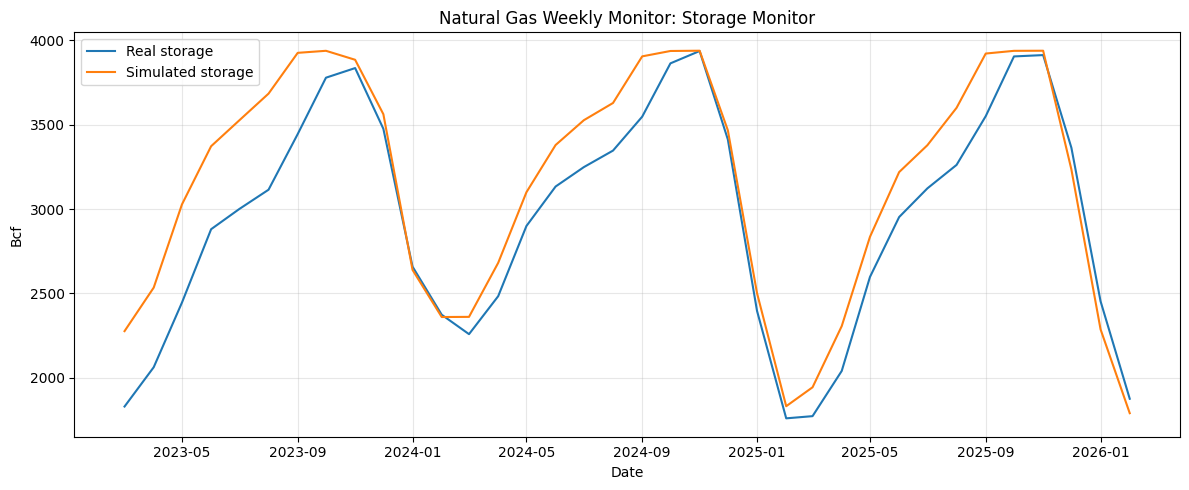

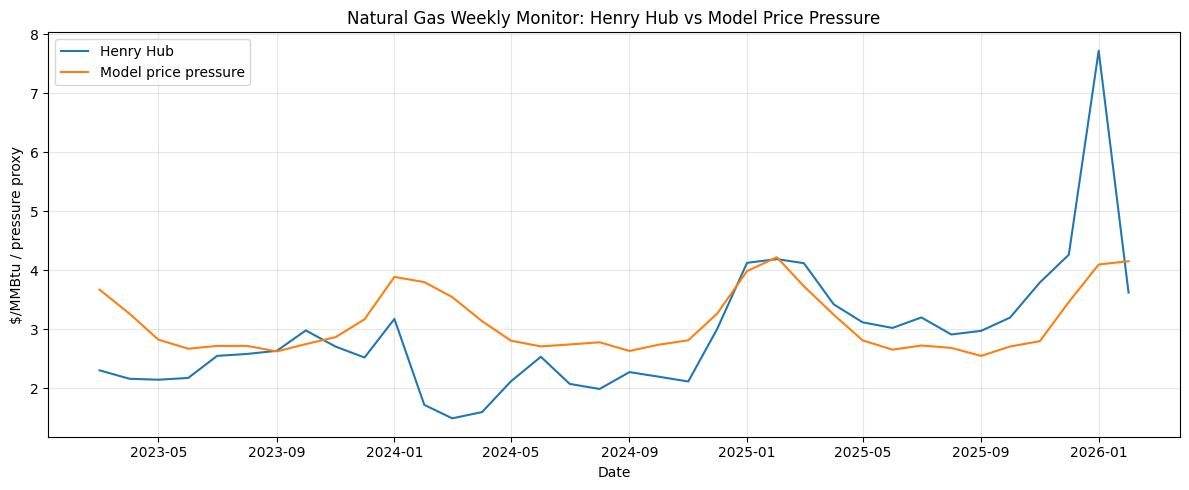

In [70]:
def plot_storage_monitor(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["storage_real"], label="Real storage")
    plt.plot(report_df["date"], report_df["storage_end_sim"], label="Simulated storage")
    plt.title(f"{REPORT_TITLE}: Storage Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_price_pressure_monitor(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["price_real"], label="Henry Hub")
    plt.plot(report_df["date"], report_df["price_pressure_sim"], label="Model price pressure")
    plt.title(f"{REPORT_TITLE}: Henry Hub vs Model Price Pressure")
    plt.xlabel("Date")
    plt.ylabel("$/MMBtu / pressure proxy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_storage_monitor(report_df)
plot_price_pressure_monitor(report_df)


## 11. Weekly chart pack — supply, demand, and balance

Use these diagnostics to explain *why* storage or price pressure is changing.


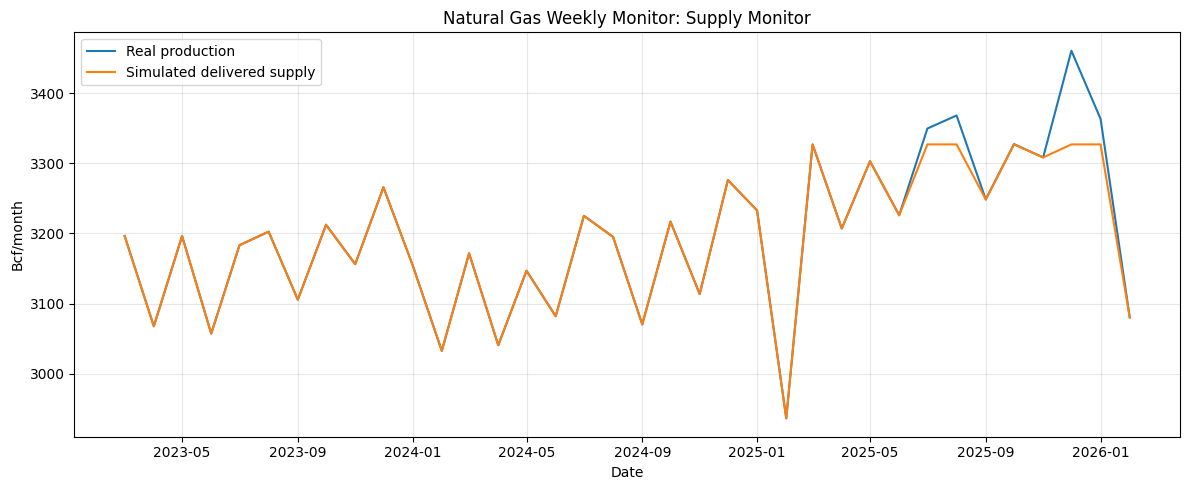

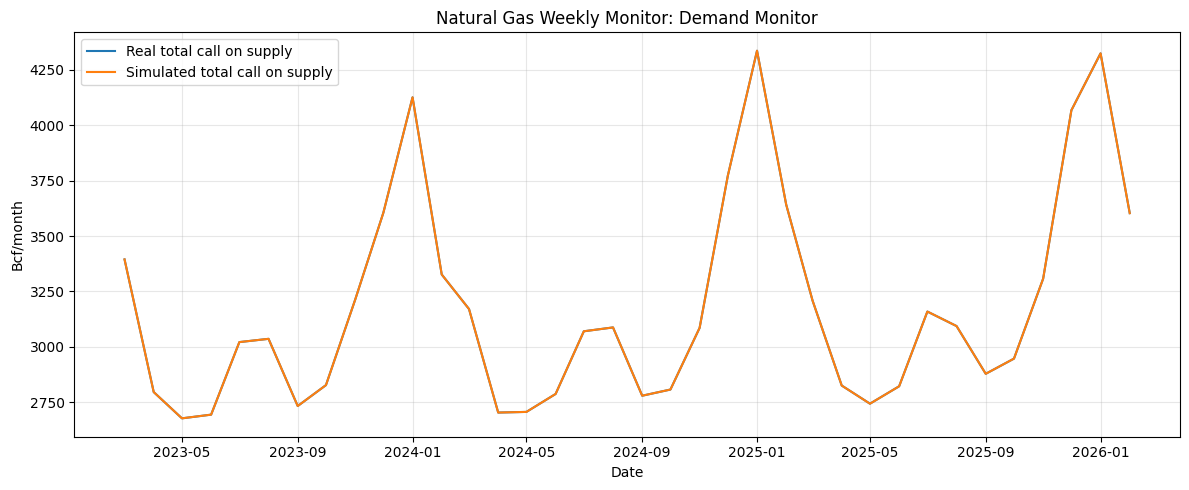

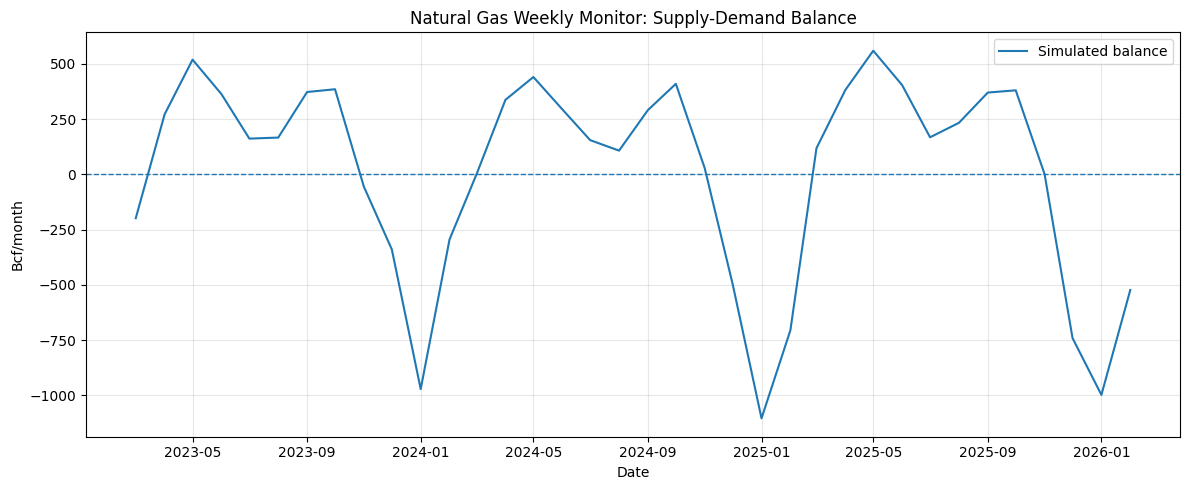

In [71]:
def plot_supply_demand_balance(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["supply_real"], label="Real production")
    plt.plot(report_df["date"], report_df["delivered_supply_bcf"], label="Simulated delivered supply")
    plt.title(f"{REPORT_TITLE}: Supply Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    real_demand_col = "total_demand_real" if "total_demand_real" in report_df.columns else "demand_real"
    plt.plot(report_df["date"], report_df[real_demand_col], label="Real total call on supply")
    plt.plot(report_df["date"], report_df["demand_sim"], label="Simulated total call on supply")
    plt.title(f"{REPORT_TITLE}: Demand Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["balance_bcf"], label="Simulated balance")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{REPORT_TITLE}: Supply-Demand Balance")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_supply_demand_balance(report_df)

## 12. Pressure z-score and classification

This converts the pressure model into a reporting signal:

- Bullish / Bearish / Neutral
- Expected / Elevated / Extreme


In [72]:
def classify_pressure_z(z):
    if z >= 1.5:
        return "Extreme Bullish"
    if z >= 0.5:
        return "Bullish"
    if z <= -1.5:
        return "Extreme Bearish"
    if z <= -0.5:
        return "Bearish"
    return "Neutral"


def classify_extremeness(z):
    if abs(z) >= 1.5:
        return "Extreme"
    if abs(z) >= 0.5:
        return "Elevated"
    return "Expected"


def add_pressure_zscores(df, baseline=None, pressure_col="price_pressure_sim"):
    out = df.copy()
    if baseline is None:
        baseline = out[pressure_col]
    mu = float(pd.to_numeric(baseline, errors="coerce").mean())
    sigma = float(pd.to_numeric(baseline, errors="coerce").std(ddof=1))
    if sigma == 0 or not np.isfinite(sigma):
        sigma = 1.0
    out["pressure_z"] = (out[pressure_col] - mu) / sigma
    out["pressure_signal"] = out["pressure_z"].apply(classify_pressure_z)
    out["pressure_extremeness"] = out["pressure_z"].apply(classify_extremeness)
    return out

best_comparison = add_pressure_zscores(best_comparison, baseline=best_comparison["price_pressure_sim"])
report_df = get_recent_window(best_comparison, months=REPORT_LOOKBACK_MONTHS)

report_df[["date", "price_real", "price_pressure_sim", "pressure_z", "pressure_signal", "pressure_extremeness"]].tail(12)


,date,price_real,price_pressure_sim,pressure_z,pressure_signal,pressure_extremeness
86,2025-03-01,4.120000,3.730,0.746572,Bullish,Elevated
87,2025-04-01,3.423333,3.247,-0.041823,Neutral,Expected
88,2025-05-01,3.118571,2.813,-0.750236,Bearish,Elevated
89,2025-06-01,3.024000,2.656,-1.006505,Bearish,Elevated
90,2025-07-01,3.201364,2.726,-0.892245,Bearish,Elevated
91,2025-08-01,2.912857,2.686,-0.957537,Bearish,Elevated
92,2025-09-01,2.974286,2.550,-1.179528,Bearish,Elevated
93,2025-10-01,3.199091,2.709,-0.919994,Bearish,Elevated
94,2025-11-01,3.794118,2.800,-0.771456,Bearish,Elevated
95,2025-12-01,4.263810,3.463,0.310751,Neutral,Expected


## 13. Next-quarter Monte Carlo forecast

The forward view now uses Monte Carlo simulation.

For each scenario, the notebook reports:
- Expected path
- Min / max path
- 10th / 90th percentile range

Use these outputs to frame next-quarter trend direction and whether conditions look expected, elevated, or extreme.


In [73]:
latest_storage = float(backtest_panel["storage_bcf"].iloc[-1])

forward_scenarios = {
    "Base 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **BASE_FORWARD),
    "Cold + LNG 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **COLD_LNG_FORWARD),
    "Loose Supply 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **LOOSE_SUPPLY_FORWARD),
}

# Apply tuned pressure parameters from the historical grid search to each forward scenario.
for s in forward_scenarios.values():
    s["storage_price_sensitivity"] = best["storage_price_sensitivity"]
    s["storage_change_price_sensitivity"] = best["storage_change_price_sensitivity"]
    s["price_inertia"] = best["price_inertia"]
    s["use_weather_demand"] = True


# Extract only the weather columns for Monte Carlo sampling.
weather_df = monthly_with_weather[["hdd", "cdd"]].dropna().copy()


def simulate_weather_paths(weather_df, months=3, n=500, seed=42, lookback_months=36, method="bootstrap"):
    """
    Generate future HDD/CDD paths.

    method='bootstrap' samples from recent real monthly HDD/CDD observations.
    This preserves realistic HDD/CDD combinations better than independent Gaussian draws.
    """
    rng = np.random.default_rng(seed)
    hist = weather_df.dropna(subset=["hdd", "cdd"]).tail(lookback_months).reset_index(drop=True)
    if hist.empty:
        raise ValueError("No HDD/CDD history available for weather Monte Carlo.")

    paths = []
    for i in range(n):
        if method == "bootstrap":
            idx = rng.integers(0, len(hist), size=months)
            df = hist.loc[idx, ["hdd", "cdd"]].reset_index(drop=True)
        else:
            hdd = rng.normal(hist["hdd"].mean(), hist["hdd"].std(ddof=1), months)
            cdd = rng.normal(hist["cdd"].mean(), hist["cdd"].std(ddof=1), months)
            df = pd.DataFrame({"hdd": np.clip(hdd, 0, None), "cdd": np.clip(cdd, 0, None)})
        paths.append(df)
    return paths


def run_monte_carlo_scenario(name, scenario, weather_paths, months=3, seed=42):
    paths = []
    for i, weather_path in enumerate(weather_paths):
        future_panel = weather_path.copy().reset_index(drop=True)

        # Supply and LNG can still vary inside GasMarket via scenario noise settings.
        future_panel["production_bcf"] = float(scenario["base_supply"])
        future_panel["lng_exports_bcf"] = float(scenario["lng_exports"])

        s = scenario.copy()
        s["use_historical_drivers"] = True
        s["use_weather_demand"] = True
        s["historical_panel"] = future_panel

        df = run_scenario(name, s, months=months, seed=seed + i)
        df["simulation"] = i
        paths.append(df)

    return pd.concat(paths, ignore_index=True)


weather_paths = simulate_weather_paths(
    weather_df,
    months=FORECAST_MONTHS,
    n=N_MONTE_CARLO,
    seed=MC_SEED,
)

forward_mc_results = pd.concat([
    run_monte_carlo_scenario(name, scenario, weather_paths, months=FORECAST_MONTHS, seed=MC_SEED)
    for name, scenario in forward_scenarios.items()
], ignore_index=True)

print("Monte Carlo storage dispersion by month:")
print(forward_mc_results.groupby(["scenario", "month"])["storage_bcf"].std().round(1))

forward_mc_results.head()

Monte Carlo storage dispersion by month:
scenario         month
Base 3M          1         69.9
                 2         98.8
                 3        127.2
Cold + LNG 3M    1         69.9
                 2         98.8
                 3        127.2
Loose Supply 3M  1         69.9
                 2         98.8
                 3        127.2
Name: storage_bcf, dtype: float64


,month,regime,price,raw_supply_bcf,delivered_supply_bcf,demand_bcf,balance_bcf,storage_start_bcf,storage_bcf,storage_change_bcf,storage_ratio,pipeline_capacity_bcf,lng_exports_bcf,scenario,simulation
0,1,neutral,3.397,2963.1,2963.1,2984.4,-21.3,1876.0,1855.8,-20.2,0.471,3326.9329,285.411051,Base 3M,0
1,2,neutral,3.387,2963.1,2963.1,2936.8,26.3,1855.8,1880.8,25.0,0.477,3326.9329,285.411051,Base 3M,0
2,3,neutral,3.428,2963.1,2963.1,2995.7,-32.6,1880.8,1849.8,-31.0,0.470,3326.9329,285.411051,Base 3M,0
3,1,neutral,3.382,2963.1,2963.1,2966.4,-3.3,1876.0,1872.8,-3.2,0.475,3326.9329,285.411051,Base 3M,1
4,2,neutral,3.329,2963.1,2963.1,2879.0,84.1,1872.8,1952.7,79.9,0.496,3326.9329,285.411051,Base 3M,1


## 14. Monte Carlo expected, min, max summary

This is the table to use for the next-quarter report.


In [74]:
def summarize_monte_carlo(mc_df):
    def q10(x):
        return x.quantile(0.10)

    def q90(x):
        return x.quantile(0.90)

    summary = (
        mc_df
        .groupby(["scenario", "month"], as_index=False)
        .agg(
            expected_price_pressure=("price", "mean"),
            min_price_pressure=("price", "min"),
            max_price_pressure=("price", "max"),
            p10_price_pressure=("price", q10),
            p90_price_pressure=("price", q90),
            expected_storage_bcf=("storage_bcf", "mean"),
            min_storage_bcf=("storage_bcf", "min"),
            max_storage_bcf=("storage_bcf", "max"),
            p10_storage_bcf=("storage_bcf", q10),
            p90_storage_bcf=("storage_bcf", q90),
            expected_storage_change_bcf=("storage_change_bcf", "mean"),
            min_storage_change_bcf=("storage_change_bcf", "min"),
            max_storage_change_bcf=("storage_change_bcf", "max"),
            expected_balance_bcf=("balance_bcf", "mean"),
            min_balance_bcf=("balance_bcf", "min"),
            max_balance_bcf=("balance_bcf", "max"),
        )
    )

    numeric_cols = summary.select_dtypes(include=[np.number]).columns
    summary[numeric_cols] = summary[numeric_cols].round(2)
    return summary


forward_mc_summary = summarize_monte_carlo(forward_mc_results)
forward_mc_summary


,scenario,month,expected_price_pressure,min_price_pressure,max_price_pressure,p10_price_pressure,p90_price_pressure,expected_storage_bcf,min_storage_bcf,max_storage_bcf,p10_storage_bcf,p90_storage_bcf,expected_storage_change_bcf,min_storage_change_bcf,max_storage_change_bcf,expected_balance_bcf,min_balance_bcf,max_balance_bcf
0,Base 3M,1,3.36,3.16,3.56,3.28,3.45,1893.35,1665.6,2127.5,1800.58,1986.43,17.35,-210.4,251.5,18.26,-221.5,264.7
1,Base 3M,2,3.38,3.18,3.58,3.28,3.47,1906.00,1613.0,2180.5,1776.73,2030.99,12.66,-173.3,235.5,13.32,-182.4,247.9
2,Base 3M,3,3.38,3.16,3.74,3.27,3.49,1917.90,1446.1,2237.7,1761.89,2080.94,11.90,-306.6,220.6,12.53,-322.7,232.2
3,Cold + LNG 3M,1,3.51,3.31,3.71,3.43,3.59,1724.55,1496.8,1958.7,1631.78,1817.63,-151.45,-379.2,82.7,-159.42,-399.2,87.0
4,Cold + LNG 3M,2,3.62,3.43,3.83,3.53,3.72,1568.40,1275.4,1842.9,1439.13,1693.39,-156.14,-342.1,66.7,-164.36,-360.1,70.2
5,Cold + LNG 3M,3,3.69,3.48,4.05,3.59,3.80,1411.50,939.7,1731.3,1255.49,1574.54,-156.90,-475.4,51.8,-165.16,-500.4,54.5
6,Loose Supply 3M,1,3.23,3.03,3.43,3.15,3.32,2041.86,1814.1,2276.0,1949.08,2135.02,165.86,-61.9,400.0,174.59,-65.2,421.0
7,Loose Supply 3M,2,3.16,2.97,3.37,3.07,3.26,2203.03,1910.0,2477.5,2073.82,2327.99,161.17,-24.7,384.0,169.65,-26.0,404.2
8,Loose Supply 3M,3,3.11,2.89,3.46,3.00,3.22,2363.44,1891.7,2683.2,2207.39,2526.53,160.41,-158.1,369.1,168.86,-166.4,388.6


## 15. Next-quarter Monte Carlo charts

Use the expected line as the base case and the min/max or 10–90% band to show uncertainty.


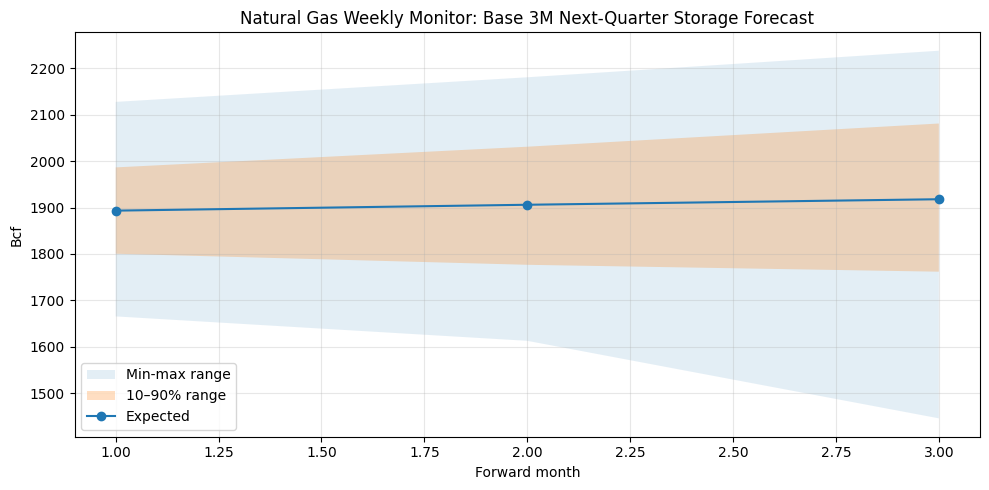

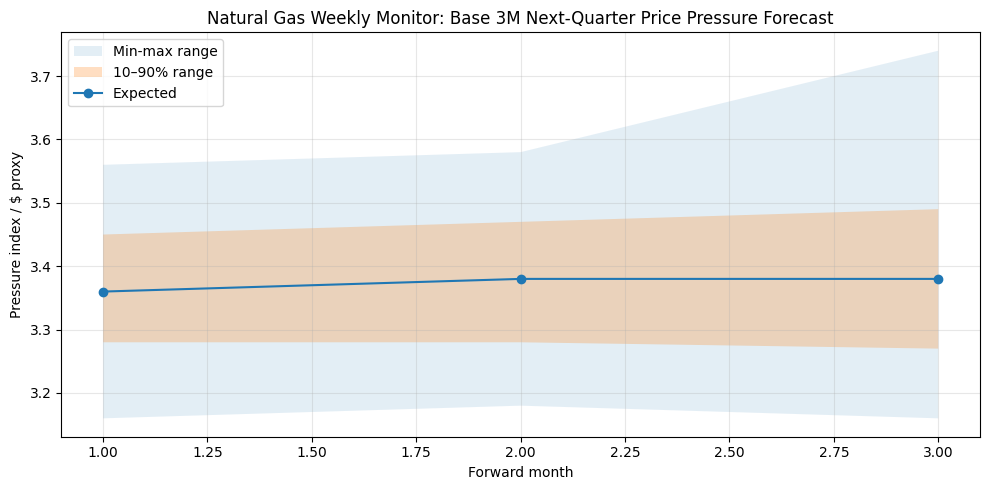

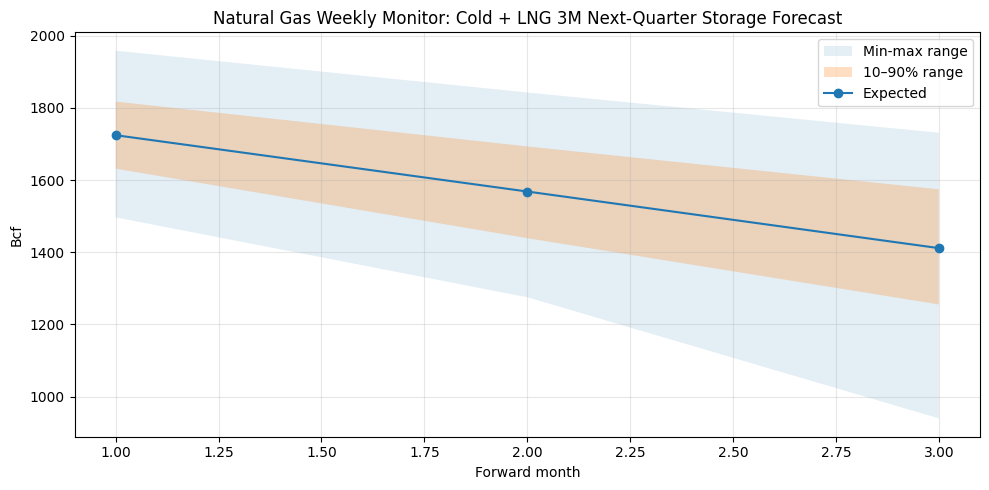

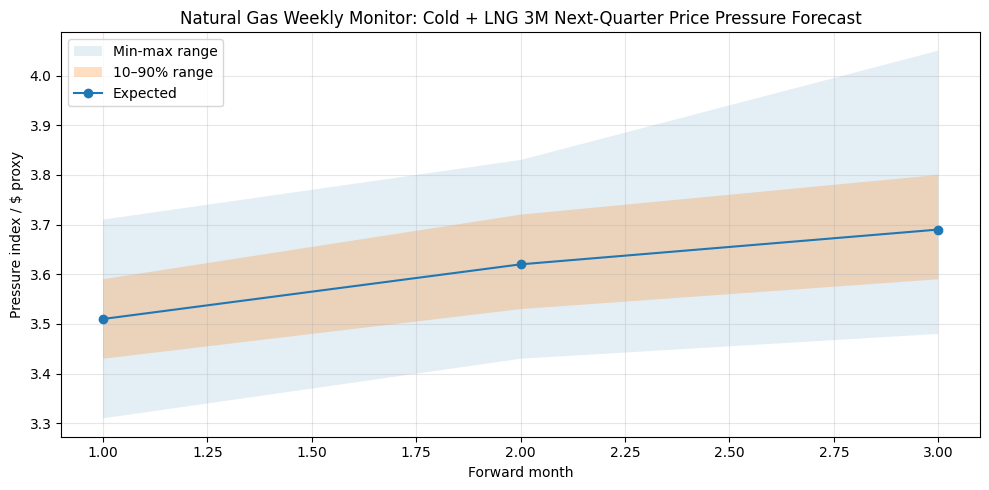

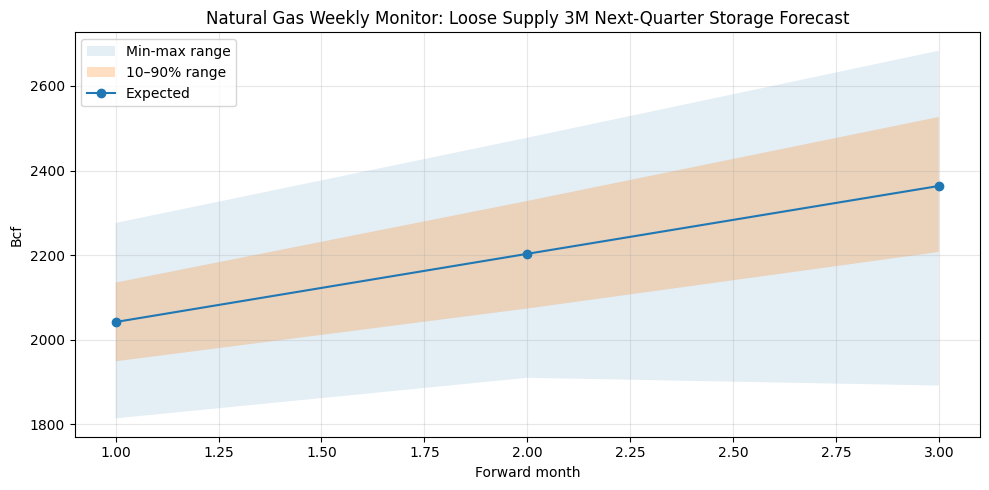

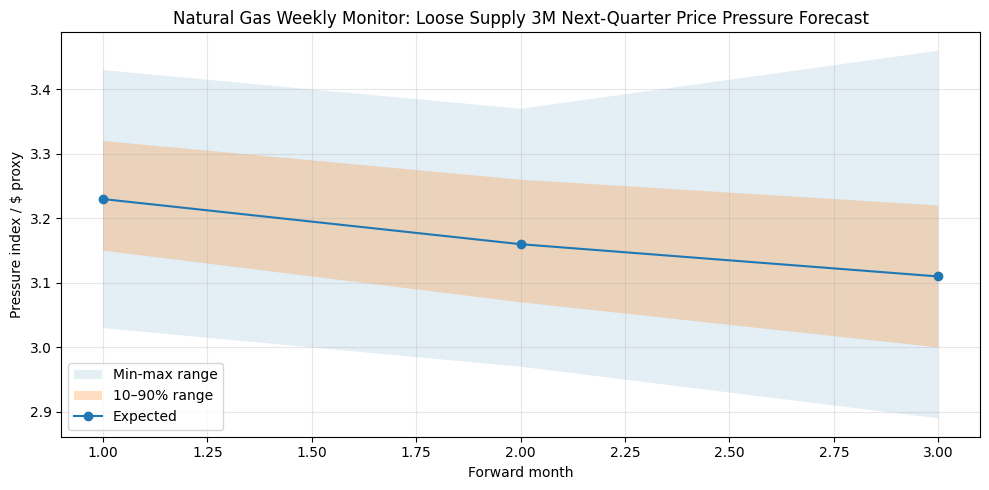

In [75]:
def plot_mc_band(summary, scenario, value_prefix, ylabel, title):
    g = summary[summary["scenario"] == scenario].copy()
    x = g["month"].to_numpy(dtype=float)
    expected = g[f"expected_{value_prefix}"].to_numpy(dtype=float)
    p10 = g[f"p10_{value_prefix}"].to_numpy(dtype=float)
    p90 = g[f"p90_{value_prefix}"].to_numpy(dtype=float)
    vmin = g[f"min_{value_prefix}"].to_numpy(dtype=float)
    vmax = g[f"max_{value_prefix}"].to_numpy(dtype=float)

    plt.figure(figsize=(10, 5))
    plt.fill_between(x, vmin, vmax, alpha=0.12, label="Min-max range")
    plt.fill_between(x, p10, p90, alpha=0.25, label="10–90% range")
    plt.plot(x, expected, marker="o", label="Expected")
    plt.title(title)
    plt.xlabel("Forward month")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for scenario in forward_mc_summary["scenario"].unique():
    plot_mc_band(
        forward_mc_summary,
        scenario,
        value_prefix="storage_bcf",
        ylabel="Bcf",
        title=f"{REPORT_TITLE}: {scenario} Next-Quarter Storage Forecast",
    )

    plot_mc_band(
        forward_mc_summary,
        scenario,
        value_prefix="price_pressure",
        ylabel="Pressure index / $ proxy",
        title=f"{REPORT_TITLE}: {scenario} Next-Quarter Price Pressure Forecast",
    )


## 16. Forward signal table

This converts Monte Carlo output into an Energy Atlas-style signal.

The signal uses expected pressure, expected storage change, and uncertainty range.


In [76]:
def _classify_storage_trend(total_storage_change_bcf):
    if total_storage_change_bcf <= -500:
        return "Tightening sharply"
    if total_storage_change_bcf <= -150:
        return "Tightening"
    if total_storage_change_bcf >= 500:
        return "Loosening sharply"
    if total_storage_change_bcf >= 150:
        return "Loosening"
    return "Balanced"


def _direction_from_storage(total_storage_change_bcf):
    if total_storage_change_bcf < -150:
        return "Bullish"
    if total_storage_change_bcf > 150:
        return "Bearish"
    return "Neutral"


def _confidence_score(pressure_z, storage_direction, pressure_label, uncertainty_width):
    z_component = min(abs(pressure_z) / 2.0, 1.0)
    pressure_direction = (
        "Bullish" if "Bullish" in pressure_label
        else "Bearish" if "Bearish" in pressure_label
        else "Neutral"
    )
    agreement_component = 1.0 if storage_direction == pressure_direction or pressure_direction == "Neutral" else 0.5
    uncertainty_component = max(0.0, 1.0 - min(uncertainty_width / 4.0, 1.0))
    return round(0.30 + 0.35 * z_component + 0.20 * agreement_component + 0.15 * uncertainty_component, 2)


def build_mc_forward_signal(summary, historical_pressure):
    hist_mean = float(historical_pressure.mean())
    hist_std = float(historical_pressure.std(ddof=1))
    if hist_std == 0 or not np.isfinite(hist_std):
        hist_std = 1.0

    signals = []
    for scenario, g in summary.groupby("scenario"):
        g = g.sort_values("month")

        avg_expected_pressure = float(g["expected_price_pressure"].mean())
        ending_expected_pressure = float(g["expected_price_pressure"].iloc[-1])
        pressure_z = (avg_expected_pressure - hist_mean) / hist_std

        pressure_label = classify_pressure_z(pressure_z)
        extremeness = classify_extremeness(pressure_z)

        total_expected_storage_change = float(g["expected_storage_change_bcf"].sum())
        storage_trend = _classify_storage_trend(total_expected_storage_change)
        storage_direction = _direction_from_storage(total_expected_storage_change)

        ending_expected_storage = float(g["expected_storage_bcf"].iloc[-1])
        ending_min_storage = float(g["min_storage_bcf"].iloc[-1])
        ending_max_storage = float(g["max_storage_bcf"].iloc[-1])

        pressure_uncertainty_width = float((g["p90_price_pressure"] - g["p10_price_pressure"]).mean())
        confidence = _confidence_score(pressure_z, storage_direction, pressure_label, pressure_uncertainty_width)

        signals.append({
            "scenario": scenario,
            "horizon_months": int(g["month"].max()),
            "price_pressure": pressure_label,
            "extremeness": extremeness,
            "pressure_z": round(pressure_z, 2),
            "expected_avg_pressure": round(avg_expected_pressure, 2),
            "expected_ending_pressure": round(ending_expected_pressure, 2),
            "p10_ending_pressure": round(float(g["p10_price_pressure"].iloc[-1]), 2),
            "p90_ending_pressure": round(float(g["p90_price_pressure"].iloc[-1]), 2),
            "storage_trend": storage_trend,
            "expected_storage_change_bcf": round(total_expected_storage_change, 1),
            "expected_ending_storage_bcf": round(ending_expected_storage, 1),
            "min_ending_storage_bcf": round(ending_min_storage, 1),
            "max_ending_storage_bcf": round(ending_max_storage, 1),
            "confidence": confidence,
        })

    return pd.DataFrame(signals).sort_values(["pressure_z"], ascending=False)


historical_pressure = pd.to_numeric(best_comparison["price_pressure_sim"], errors="coerce").dropna()
forward_signals = build_mc_forward_signal(forward_mc_summary, historical_pressure)
forward_signals


,scenario,horizon_months,price_pressure,extremeness,pressure_z,expected_avg_pressure,expected_ending_pressure,p10_ending_pressure,p90_ending_pressure,storage_trend,expected_storage_change_bcf,expected_ending_storage_bcf,min_ending_storage_bcf,max_ending_storage_bcf,confidence
1,Cold + LNG 3M,3,Bullish,Elevated,0.55,3.61,3.69,3.59,3.80,Tightening,-464.5,1411.5,939.7,1731.3,0.74
0,Base 3M,3,Neutral,Expected,0.16,3.37,3.38,3.27,3.49,Balanced,41.9,1917.9,1446.1,2237.7,0.67
2,Loose Supply 3M,3,Neutral,Expected,-0.17,3.17,3.11,3.00,3.22,Loosening,487.4,2363.4,1891.7,2683.2,0.67


## 17. Weekly report summary

This cell prints a draft text block you can use for Energy Atlas, Twitter/X, or Substack.


In [77]:
def format_energy_atlas_signal(signal):
    return (
        f"{signal['scenario']} ({signal['horizon_months']}M): "
        f"{signal['price_pressure']} pressure, {signal['extremeness'].lower()} conditions. "
        f"Expected storage path is {signal['storage_trend'].lower()} "
        f"({signal['expected_storage_change_bcf']} Bcf over the horizon). "
        f"Expected ending storage: {signal['expected_ending_storage_bcf']} Bcf "
        f"(min-max: {signal['min_ending_storage_bcf']}–{signal['max_ending_storage_bcf']} Bcf). "
        f"Confidence: {signal['confidence']:.2f}."
    )


latest = report_df.iloc[-1]
prior = report_df.iloc[-2] if len(report_df) > 1 else latest

print(f"# {REPORT_TITLE} — {REPORT_DATE.date()}")
print()
print("## Current market read")
print(
    f"Model pressure is {latest['pressure_signal']} "
    f"with a pressure z-score of {latest['pressure_z']:.2f}. "
    f"Latest storage is {latest['storage_real']:,.0f} Bcf. "
    f"The latest monthly storage change was {latest['storage_change_real']:,.0f} Bcf."
)

print()
print("## Next-quarter Monte Carlo scenarios")
for row in forward_signals.to_dict("records"):
    print("- " + format_energy_atlas_signal(row))

print()
print("## Suggested framing")
print(
    "The model should be interpreted as a directional pressure monitor, not an exact Henry Hub forecast. "
    "The key question is whether storage and balance conditions point to tightening, loosening, or normal seasonal behavior over the next quarter."
)


# Natural Gas Weekly Monitor — 2026-05-06

## Current market read
Model pressure is Bullish with a pressure z-score of 1.44. Latest storage is 1,876 Bcf. The latest monthly storage change was -578 Bcf.

## Next-quarter Monte Carlo scenarios
- Cold + LNG 3M (3M): Bullish pressure, elevated conditions. Expected storage path is tightening (-464.5 Bcf over the horizon). Expected ending storage: 1411.5 Bcf (min-max: 939.7–1731.3 Bcf). Confidence: 0.74.
- Base 3M (3M): Neutral pressure, expected conditions. Expected storage path is balanced (41.9 Bcf over the horizon). Expected ending storage: 1917.9 Bcf (min-max: 1446.1–2237.7 Bcf). Confidence: 0.67.
- Loose Supply 3M (3M): Neutral pressure, expected conditions. Expected storage path is loosening (487.4 Bcf over the horizon). Expected ending storage: 2363.4 Bcf (min-max: 1891.7–2683.2 Bcf). Confidence: 0.67.

## Suggested framing
The model should be interpreted as a directional pressure monitor, not an exact Henry Hub forecast. The key ques

## 18. Optional export

Set `EXPORT = True` if you want CSV outputs for charting or uploading elsewhere.


In [78]:
EXPORT = False

if EXPORT:
    report_df.to_csv("energy_atlas_weekly_monitor_history.csv", index=False)
    forward_mc_results.to_csv("energy_atlas_forward_monte_carlo_paths.csv", index=False)
    forward_mc_summary.to_csv("energy_atlas_forward_monte_carlo_summary.csv", index=False)
    forward_signals.to_csv("energy_atlas_forward_signals.csv", index=False)
    print("Exported weekly monitor and forward Monte Carlo CSV files.")
